# 02 - Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the Ames Housing dataset, understand feature distributions, identify potential outliers, and investigate relationships between independent variables and the target variable, `SalePrice`.

The analysis focuses on:

- Target variable distribution and skewness
- Numerical feature distributions
- Categorical feature analysis
- Outlier detection using the IQR method
- Correlation analysis
- Multicollinearity investigation
- Feature relationships with house prices

The findings will guide our preprocessing decisions, including imputation, feature encoding, outlier treatment, and scaling before implementing Batch Gradient Descent.

**Note:** This notebook performs exploratory analysis only. The original dataset will not be modified.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid", palette="deep")

RANDOM_STATE = 42
TARGET = "SalePrice"

PROJECT_ROOT = Path.cwd().parent

TRAIN_PATH = PROJECT_ROOT / "data" / "raw" / "train.csv"

train_df = pd.read_csv(TRAIN_PATH)

print("Dataset Shape: ", train_df.shape)

Dataset Shape:  (1460, 81)


In [3]:
train_df[TARGET].describe()

count     1460.00
mean    180921.20
std      79442.50
min      34900.00
25%     129975.00
50%     163000.00
75%     214000.00
max     755000.00
Name: SalePrice, dtype: float64

In [4]:
print("Skewness:", train_df[TARGET].skew())
print("Kurtosis:", train_df[TARGET].kurt())

Skewness: 1.8828757597682129
Kurtosis: 6.536281860064529


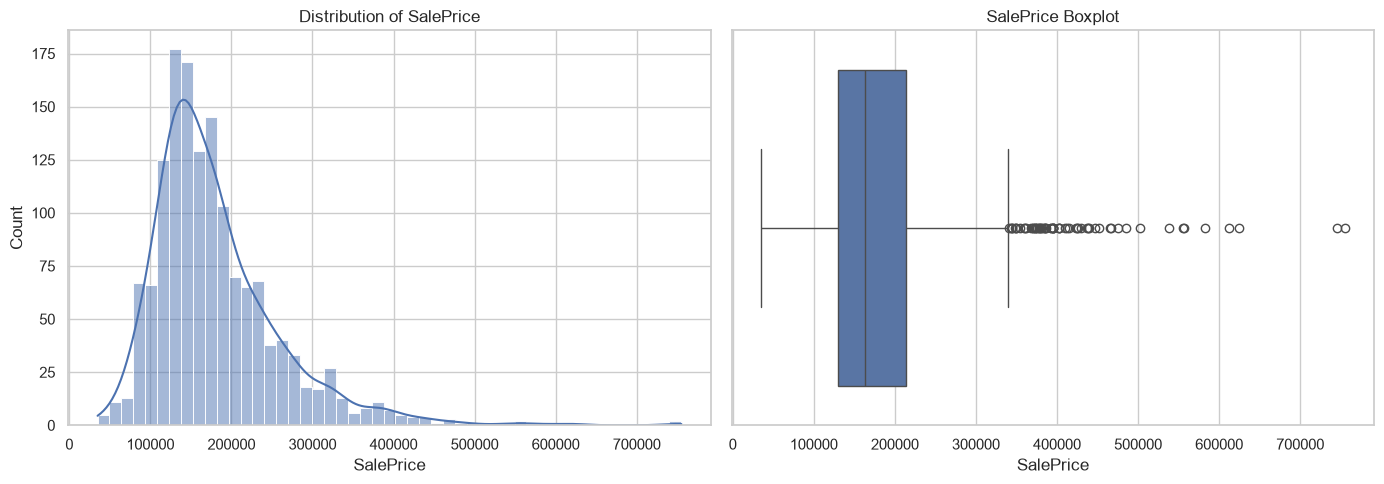

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    train_df[TARGET],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of SalePrice")
axes[0].set_xlabel("SalePrice")

sns.boxplot(
    x=train_df[TARGET],
    ax=axes[1]
)

axes[1].set_title("SalePrice Boxplot")

plt.tight_layout()
plt.show()

In [6]:
train_df["Log_SalePrice"] = np.log1p(train_df[TARGET])

print("Original Skewness: ", train_df[TARGET].skew())
print("Log Transformed Skewness: ", train_df["Log_SalePrice"].skew())

Original Skewness:  1.8828757597682129
Log Transformed Skewness:  0.12134661989685329


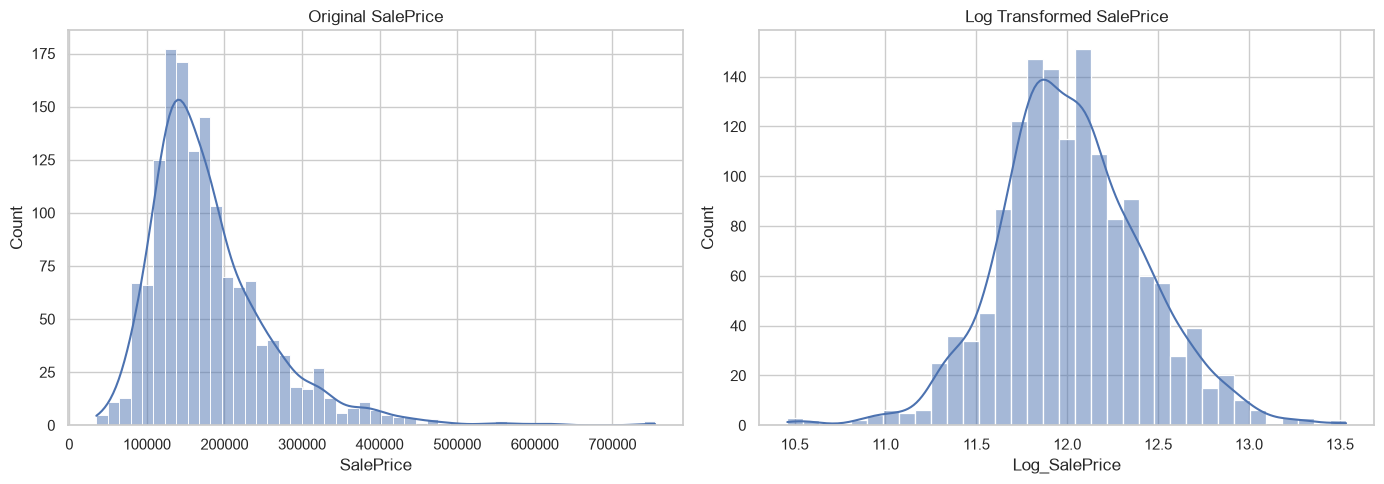

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    train_df[TARGET],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Original SalePrice")

sns.histplot(
    train_df["Log_SalePrice"],
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Log Transformed SalePrice")

plt.tight_layout()
plt.show()

In [8]:
numerical_features = train_df.select_dtypes(include="number").columns.tolist()

numerical_features = [col for col in numerical_features if col not in ["Id", TARGET, "Log_SalePrice"]]

print("Number of Numerical Predictors: ", len(numerical_features))

Number of Numerical Predictors:  36


In [9]:
numerical_summary = train_df[numerical_features].describe().T

numerical_summary["skewness"] = train_df[numerical_features].skew()
numerical_summary["missing_percentage"] = train_df[numerical_features].isnull().mean() * 100

numerical_summary.sort_values(by="skewness", ascending=False)

,count,mean,std,min,25%,50%,75%,max,skewness,missing_percentage
MiscVal,1460.00,43.49,496.12,0.00,0.00,0.00,0.00,15500.00,24.48,0.00
PoolArea,1460.00,2.76,40.18,0.00,0.00,0.00,0.00,738.00,14.83,0.00
LotArea,1460.00,10516.83,9981.26,1300.00,7553.50,9478.50,11601.50,215245.00,12.21,0.00
3SsnPorch,1460.00,3.41,29.32,0.00,0.00,0.00,0.00,508.00,10.30,0.00
LowQualFinSF,1460.00,5.84,48.62,0.00,0.00,0.00,0.00,572.00,9.01,0.00
KitchenAbvGr,1460.00,1.05,0.22,0.00,1.00,1.00,1.00,3.00,4.49,0.00
BsmtFinSF2,1460.00,46.55,161.32,0.00,0.00,0.00,0.00,1474.00,4.26,0.00
ScreenPorch,1460.00,15.06,55.76,0.00,0.00,0.00,0.00,480.00,4.12,0.00
BsmtHalfBath,1460.00,0.06,0.24,0.00,0.00,0.00,0.00,2.00,4.10,0.00
EnclosedPorch,1460.00,21.95,61.12,0.00,0.00,0.00,0.00,552.00,3.09,0.00


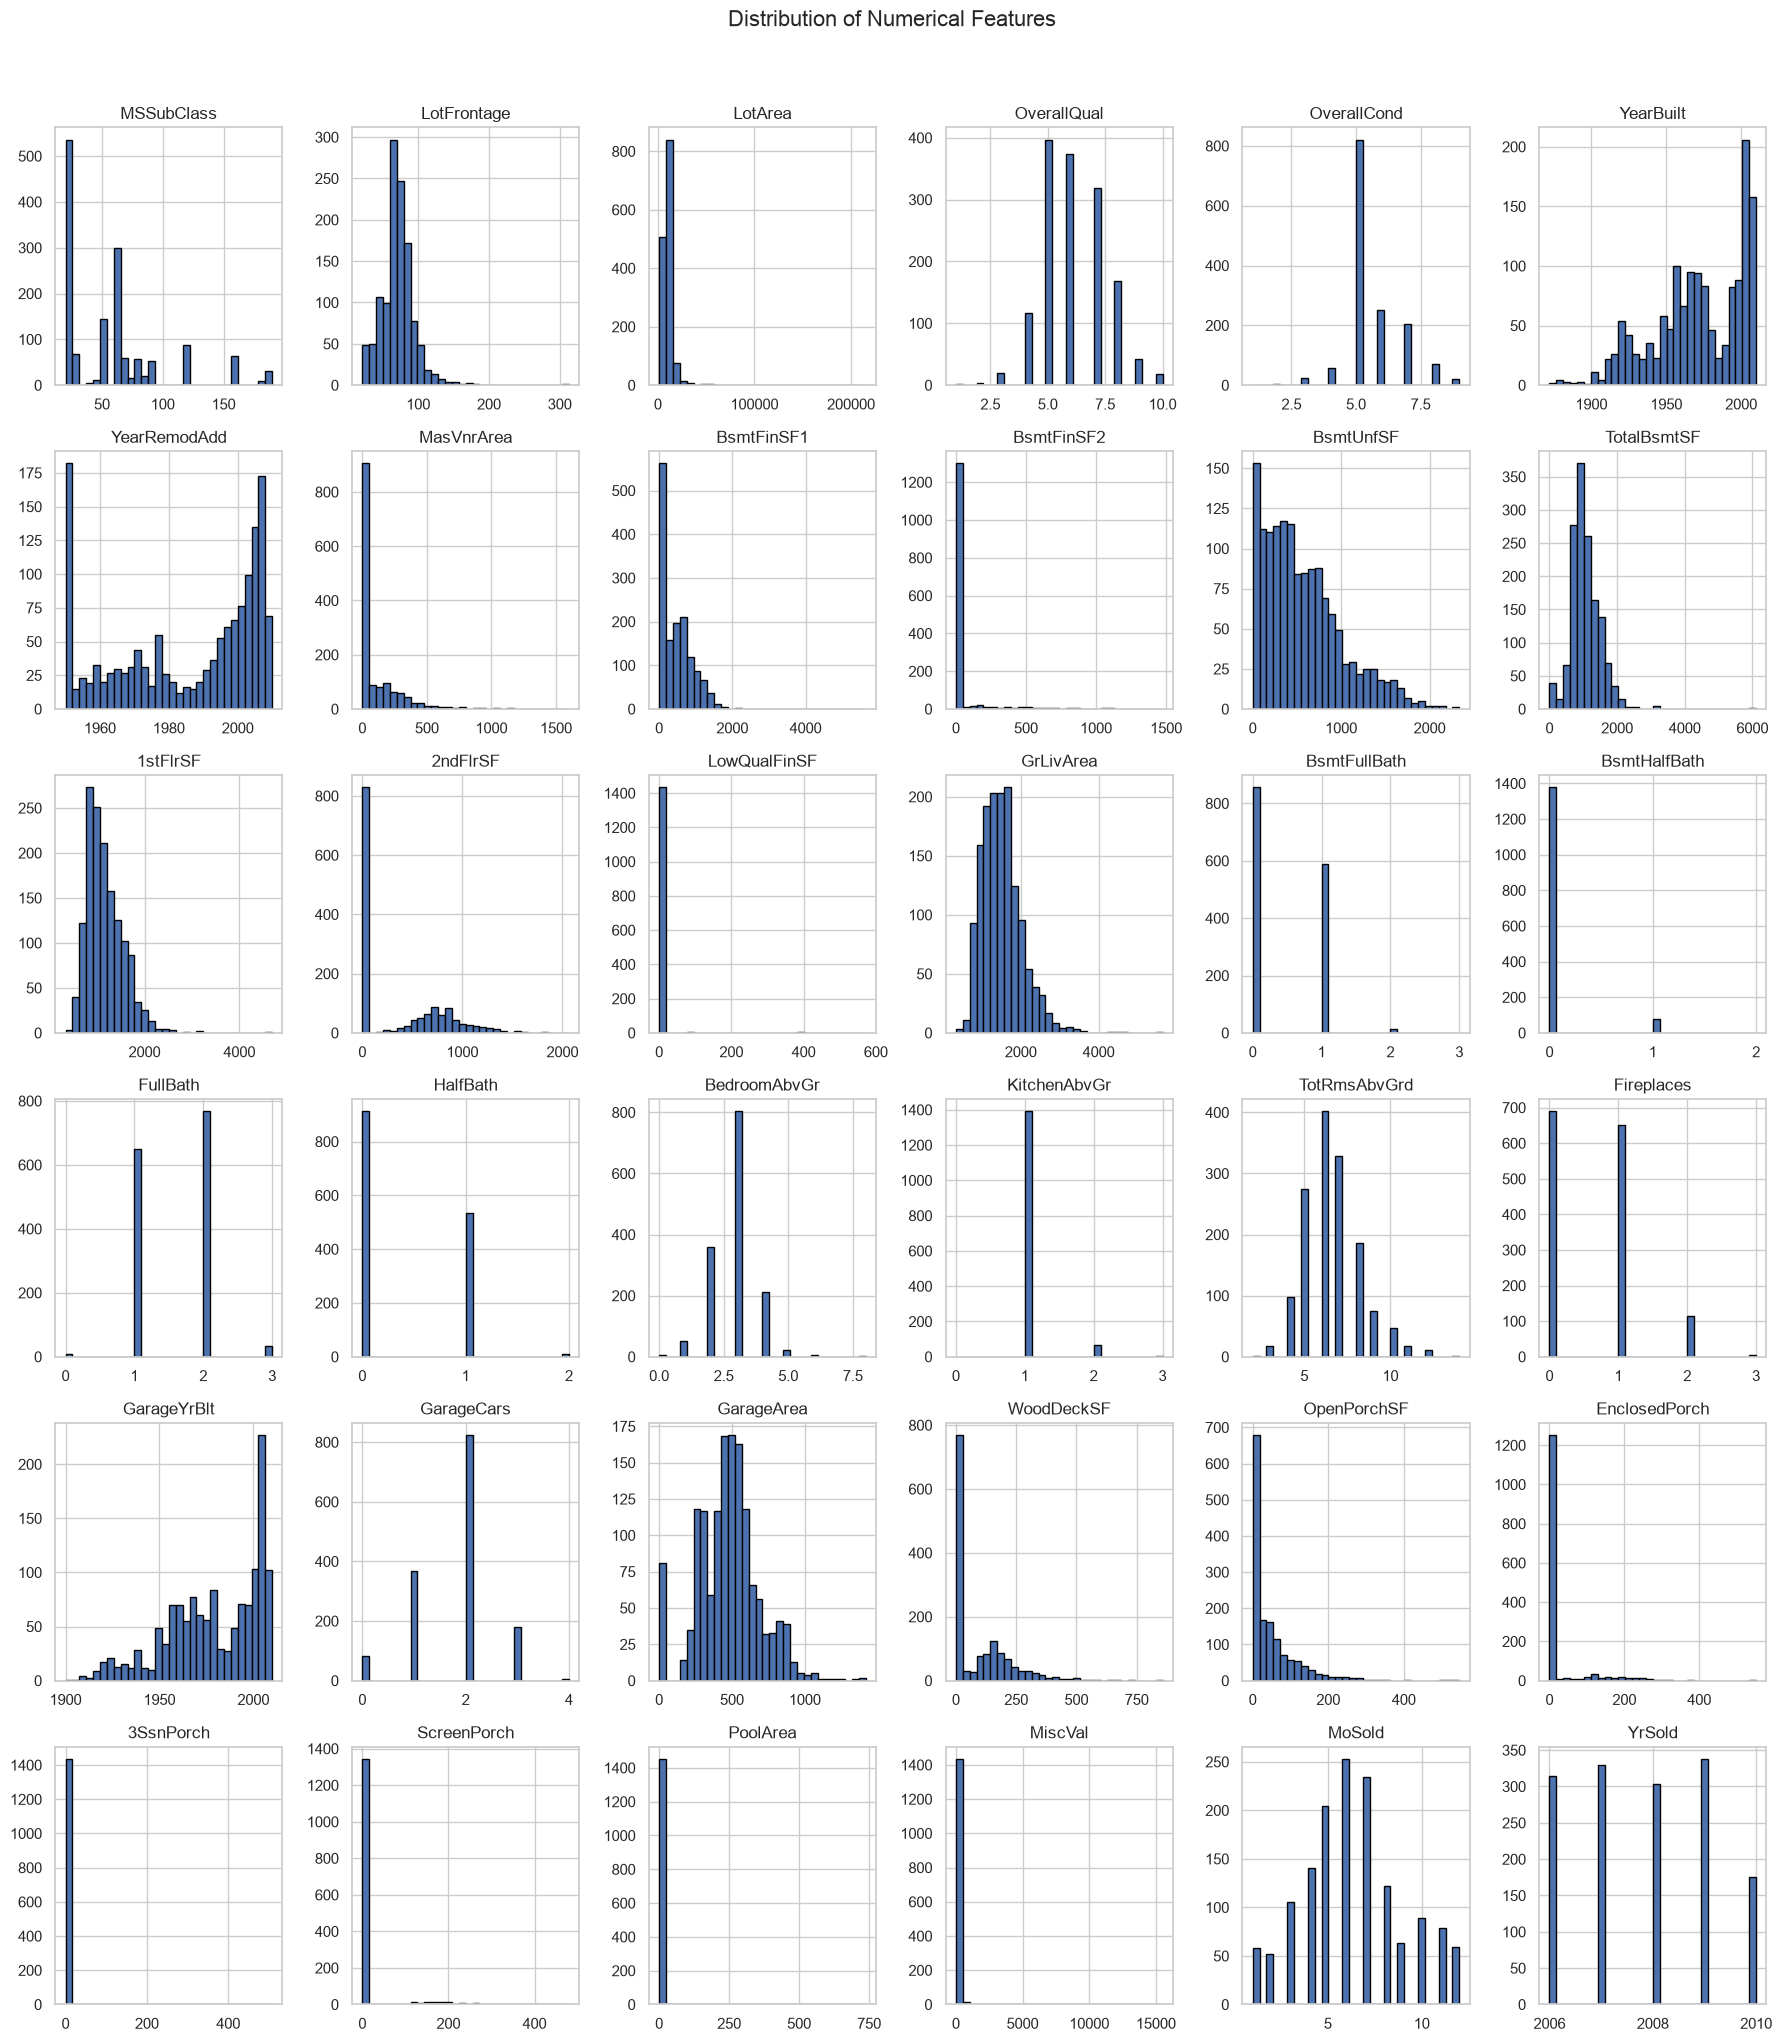

In [10]:
train_df[numerical_features].hist(figsize=(18, 20), bins=30, edgecolor="black")

plt.suptitle("Distribution of Numerical Features", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

In [31]:
def detect_outliers_iqr(df, columns):
    results = []

    for col in columns:
        series = pd.Series(df[col])

        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()

        results.append({
            "Feature": col,
            "Lower_Bound": lower_bound,
            "Upper_Bound": upper_bound,
            "Outlier_Count": outlier_count,
            "Outlier_Percentage": (outlier_count / len(series)) * 100
        })

    return pd.DataFrame(results)


In [32]:
outlier_summary = detect_outliers_iqr(train_df, numerical_features)

outlier_summary.sort_values(by="Outlier_Percentage", ascending=False)

,Feature,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
29,EnclosedPorch,0.00,0.00,208,14.25
9,BsmtFinSF2,0.00,0.00,167,11.44
4,OverallCond,3.50,7.50,125,8.56
31,ScreenPorch,0.00,0.00,116,7.95
0,MSSubClass,-55.00,145.00,103,7.05
7,MasVnrArea,-249.00,415.00,96,6.58
1,LotFrontage,27.50,111.50,88,6.03
17,BsmtHalfBath,0.00,0.00,82,5.62
28,OpenPorchSF,-102.00,170.00,77,5.27
2,LotArea,1481.50,17673.50,69,4.73


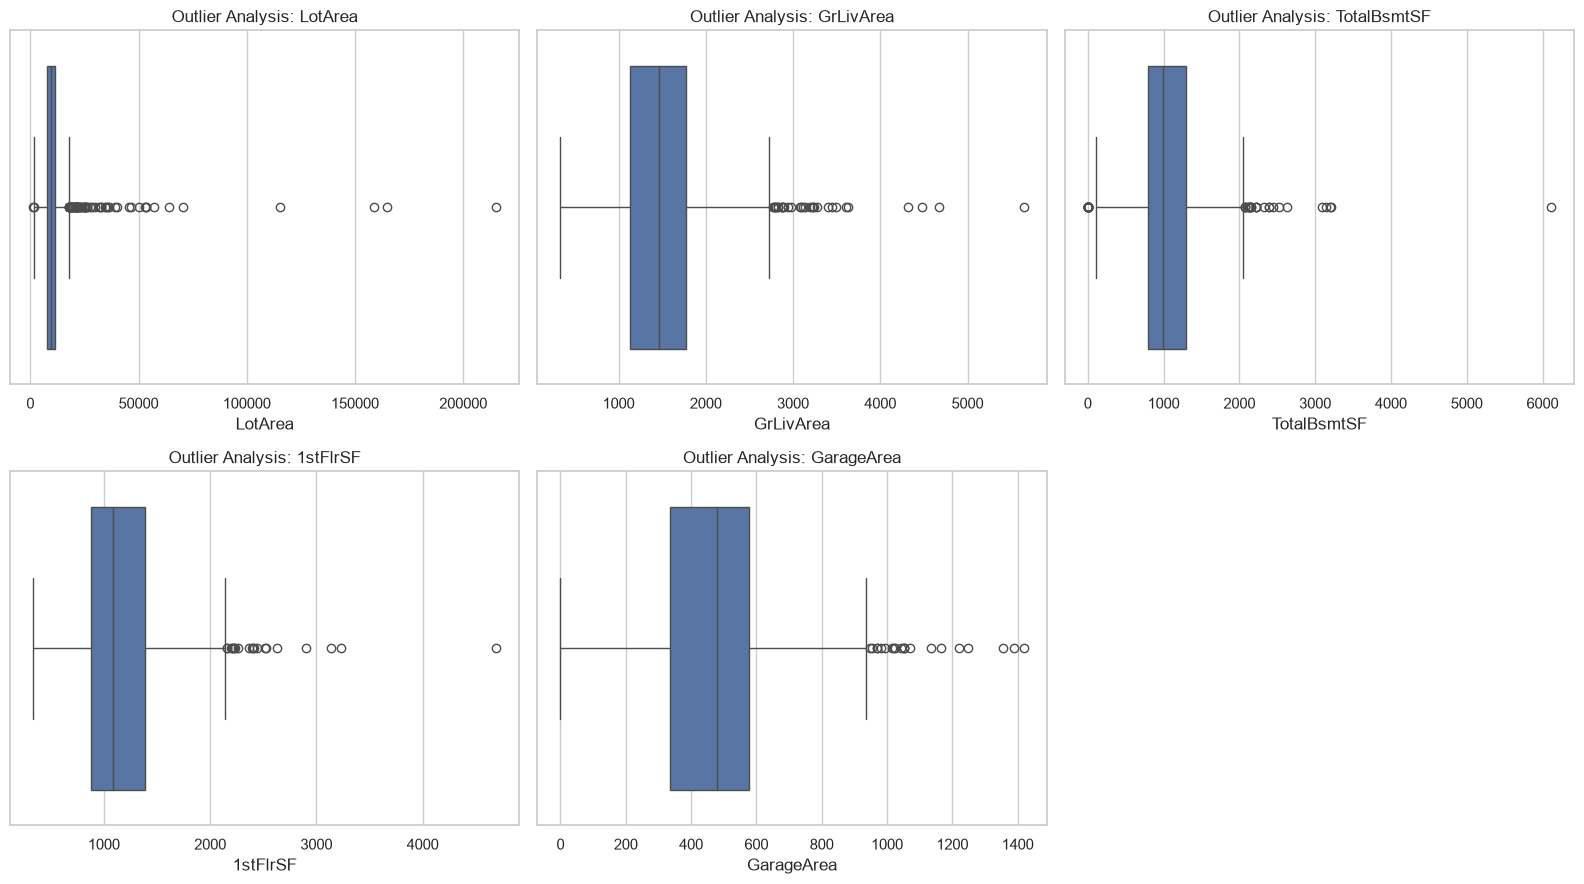

In [33]:
selected_features = ["LotArea", "GrLivArea", "TotalBsmtSF", "1stFlrSF", "GarageArea"]

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 9)
)

axes = axes.flatten()

for i, col in enumerate(selected_features):
    sns.boxplot(
        x=train_df[col],
        ax=axes[i]
    )

    axes[i].set_title(f"Outlier Analysis: {col}")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [35]:
categorical_featurs = train_df.select_dtypes(include="str").columns.tolist()

print("Categorical Features: ", len(categorical_featurs))

Categorical Features:  43


In [37]:
cardinality = pd.DataFrame({
    "Unique_Count": train_df[categorical_featurs].nunique(),
    "Missing_Count": train_df[categorical_featurs].isnull().sum()
})

cardinality.sort_values(by="Unique_Count", ascending=False)

,Unique_Count,Missing_Count
Neighborhood,25,0
Exterior2nd,16,0
Exterior1st,15,0
SaleType,9,0
Condition1,9,0
Condition2,8,0
HouseStyle,8,0
RoofMatl,8,0
Functional,7,0
BsmtFinType2,6,38


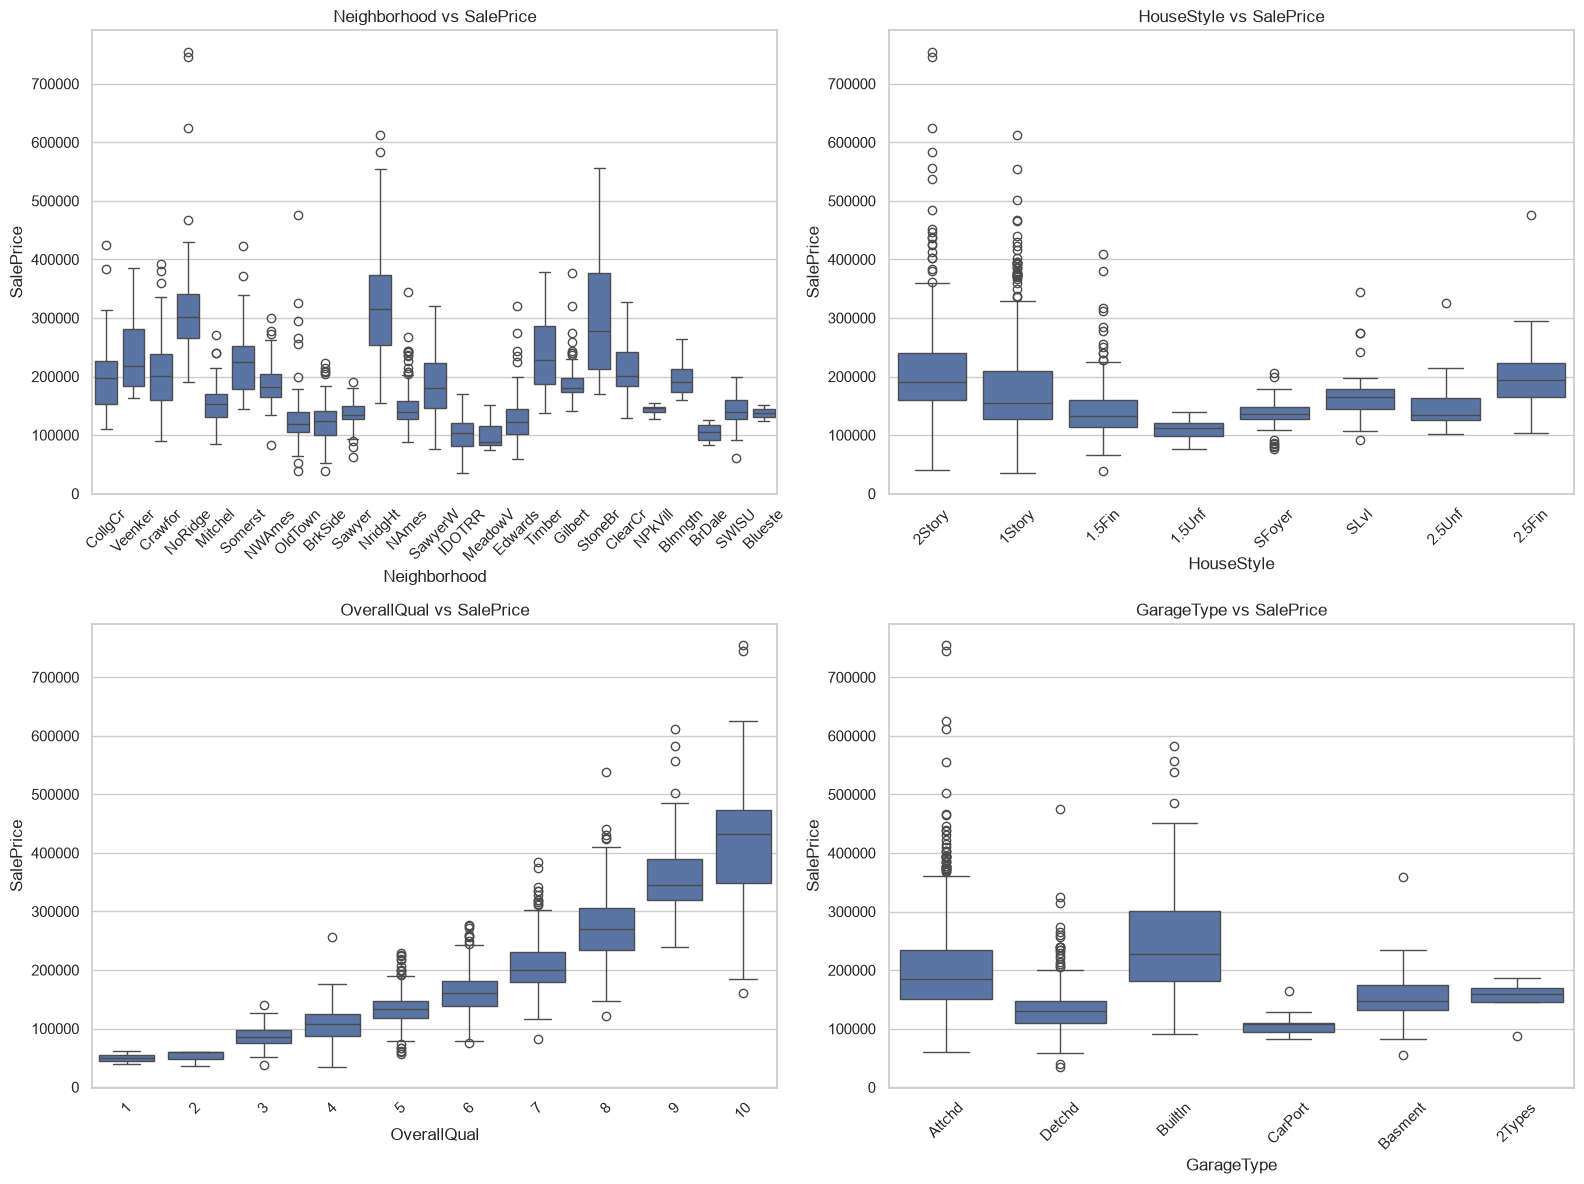

In [38]:
selected_categorical = ["Neighborhood", "HouseStyle", "OverallQual", "GarageType"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes = axes.flatten()

for i, col in enumerate(selected_categorical):

    sns.boxplot(
        data=train_df,
        x=col,
        y=TARGET,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs SalePrice")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [44]:
correlation_with_target = (
    train_df[numerical_features + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(ascending=False)
)

correlation_with_target

OverallQual      0.79
GrLivArea        0.71
GarageCars       0.64
GarageArea       0.62
TotalBsmtSF      0.61
1stFlrSF         0.61
FullBath         0.56
TotRmsAbvGrd     0.53
YearBuilt        0.52
YearRemodAdd     0.51
GarageYrBlt      0.49
MasVnrArea       0.48
Fireplaces       0.47
BsmtFinSF1       0.39
LotFrontage      0.35
WoodDeckSF       0.32
2ndFlrSF         0.32
OpenPorchSF      0.32
HalfBath         0.28
LotArea          0.26
BsmtFullBath     0.23
BsmtUnfSF        0.21
BedroomAbvGr     0.17
ScreenPorch      0.11
PoolArea         0.09
MoSold           0.05
3SsnPorch        0.04
BsmtFinSF2      -0.01
BsmtHalfBath    -0.02
MiscVal         -0.02
LowQualFinSF    -0.03
YrSold          -0.03
OverallCond     -0.08
MSSubClass      -0.08
EnclosedPorch   -0.13
KitchenAbvGr    -0.14
Name: SalePrice, dtype: float64

In [45]:
top_positive = correlation_with_target.head(10)

top_negative = correlation_with_target.tail(10)

print("Top Positive Correlations:")
display(top_positive)

print("\nTop Negative Correlations:")
display(top_negative)

Top Positive Correlations:


OverallQual    0.79
GrLivArea      0.71
GarageCars     0.64
GarageArea     0.62
TotalBsmtSF    0.61
1stFlrSF       0.61
FullBath       0.56
TotRmsAbvGrd   0.53
YearBuilt      0.52
YearRemodAdd   0.51
Name: SalePrice, dtype: float64


Top Negative Correlations:


3SsnPorch        0.04
BsmtFinSF2      -0.01
BsmtHalfBath    -0.02
MiscVal         -0.02
LowQualFinSF    -0.03
YrSold          -0.03
OverallCond     -0.08
MSSubClass      -0.08
EnclosedPorch   -0.13
KitchenAbvGr    -0.14
Name: SalePrice, dtype: float64

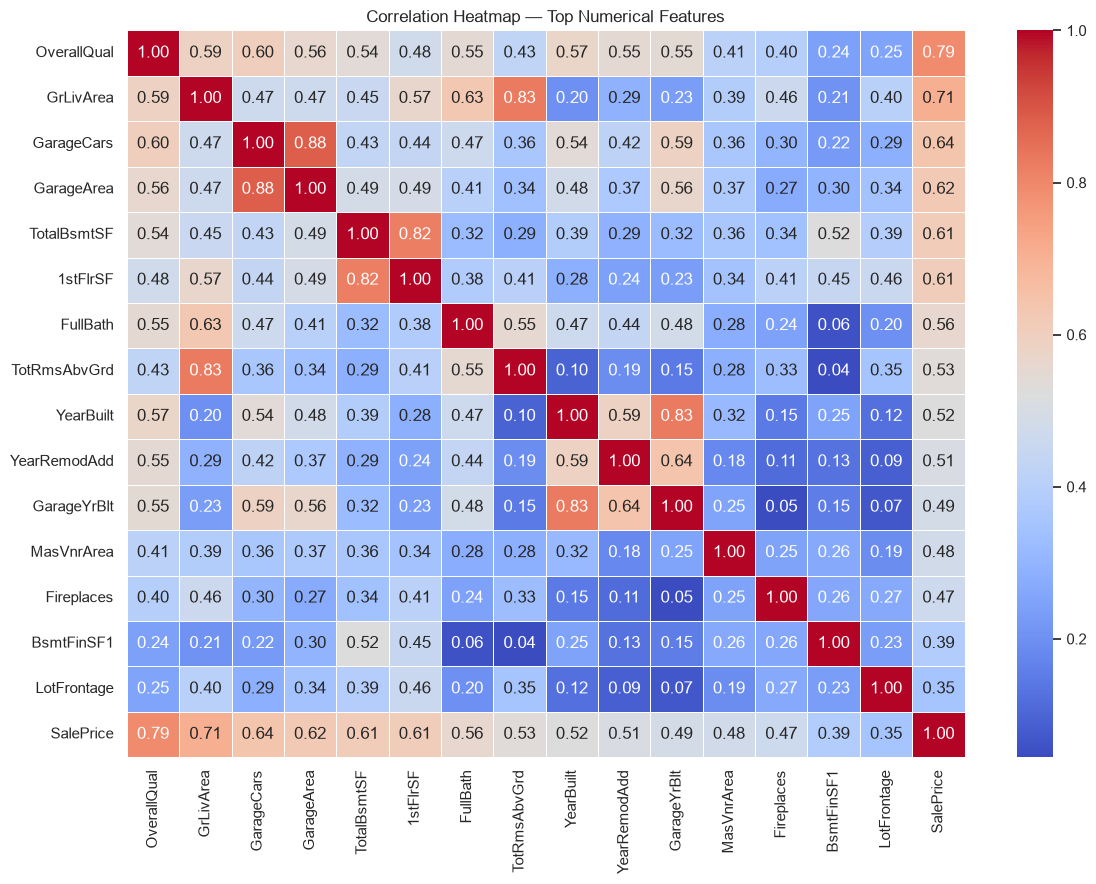

In [46]:
top_correlated_features = (
    correlation_with_target.abs()
    .sort_values(ascending=False)
    .head(15)
    .index.tolist()
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    train_df[top_correlated_features + [TARGET]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap — Top Numerical Features")

plt.tight_layout()
plt.show()

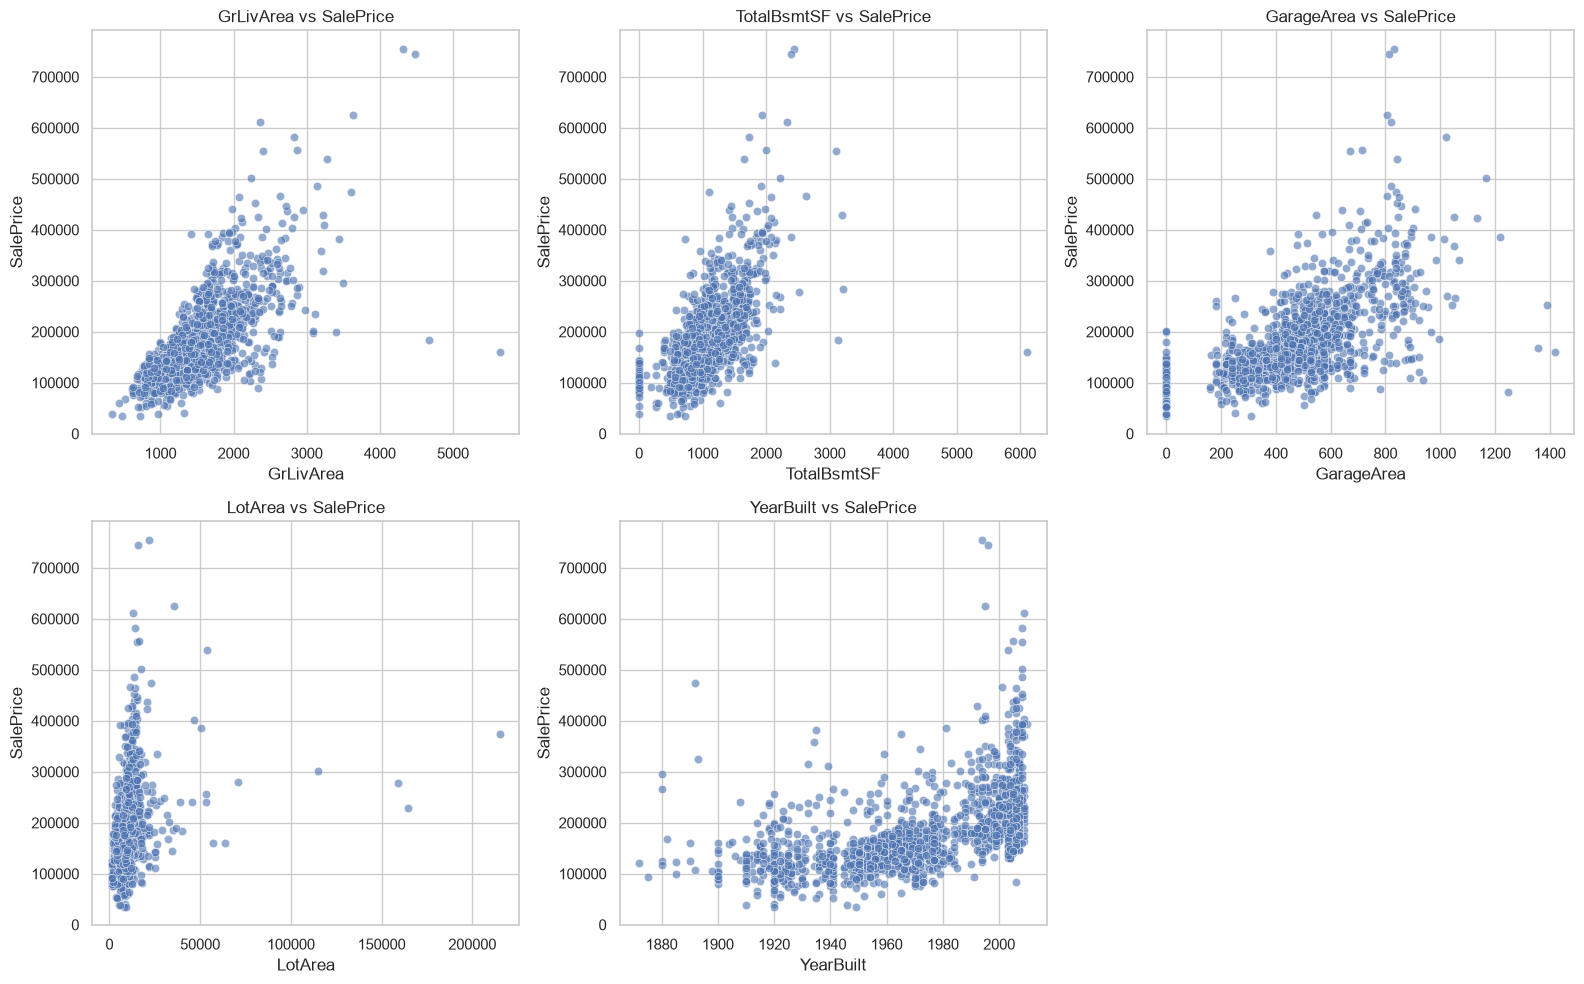

In [47]:
selected_numerical = ["GrLivArea", "TotalBsmtSF", "GarageArea", "LotArea", "YearBuilt"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes = axes.flatten()

for i, col in enumerate(selected_numerical):

    sns.scatterplot(
        data=train_df,
        x=col,
        y=TARGET,
        alpha=0.6,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs SalePrice")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

## Key Findings

The exploratory data analysis provided insights into the distributions, relationships, and statistical characteristics of the Ames Housing dataset.

### Target Variable
- `SalePrice` exhibits a [right-skewed / approximately symmetric] distribution.
- Log transformation [reduces / does not substantially reduce] target skewness.
- The target distribution indicates the need to investigate residual behavior during model evaluation.

### Numerical Features
- Numerical predictors have varying measurement scales and distributions.
- Several features exhibit skewness and potential outliers.
- Feature scaling will be necessary for stable and efficient Gradient Descent optimization.

### Categorical Features
- Property characteristics such as neighborhood, house style, and garage type show differences in house-price distributions.
- Categorical encoding will be required before model training.

### Outlier Analysis
- The IQR method identifies potential outliers in several numerical variables.
- These observations require contextual evaluation rather than automatic removal.

### Correlation Analysis
- Certain numerical features exhibit meaningful linear associations with `SalePrice`.
- Some predictors show correlations with each other, indicating potential multicollinearity.

### Preprocessing Implications
Based on the analysis, the next stage will involve:

1. Handling missing values using appropriate numerical and categorical imputation strategies.
2. Encoding categorical variables using One-Hot Encoding.
3. Applying feature scaling using StandardScaler.
4. Investigating skewed features and selected transformations.
5. Creating a reproducible training-validation preprocessing pipeline.

The dataset is now better understood and ready for systematic preprocessing before implementing our custom Batch Gradient Descent optimizer.